In [3]:
"""
Shadow Computation for Charged Galactic Wormhole
"""

'\nShadow Computation for Charged Galactic Wormhole\n'

In [10]:
%matplotlib inline

In [11]:
import sys; sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import yaml

In [12]:
with open('../config/params.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

In [13]:
rho_s = config['dark_matter']['rho_s']
r_s = config['dark_matter']['r_s']
C1 = config['wormhole']['C1']
Q = config['wormhole']['Q']

In [21]:
from src.dark_matter import DarkMatterProfile
from src.shape_function import ShapeFunction
from src.metric import ChargedWormholeMetric
from src.shadow import WormholeShadow

sf = ShapeFunction(rho_s, r_s, C1, Q)
metric = ChargedWormholeMetric(sf)

print("Generating shadow...")
shadow = WormholeShadow(metric, observer_inclination=17)
shadow_image = shadow.generate_shadow(N_pixels=200, alpha_max=20, beta_max=20)

Generating shadow...


100%|██████████| 200/200 [00:00<00:00, 12250.08it/s]


In [22]:
print(f"Shadow image shape: {shadow_image.shape}")
print(f"Unique values: {np.unique(shadow_image)}")
print(f"Dark pixels (0): {np.sum(shadow_image == 0)}")
print(f"Bright pixels (1): {np.sum(shadow_image == 1)}")

Shadow image shape: (200, 200)
Unique values: [0. 1.]
Dark pixels (0): 31064
Bright pixels (1): 8936


In [28]:
print(f"Shape: {shadow_image.shape}")
print(f"Min value: {shadow_image.min()}")
print(f"Max value: {shadow_image.max()}")
print(f"Unique values: {np.unique(shadow_image)}")
print(f"Number of zeros: {np.sum(shadow_image == 0)}")
print(f"Number of ones: {np.sum(shadow_image == 1)}")
print(f"All pixels same? {np.all(shadow_image == shadow_image[0,0])}")


Shape: (200, 200)
Min value: 0.0
Max value: 1.0
Unique values: [0. 1.]
Number of zeros: 31064
Number of ones: 8936
All pixels same? False


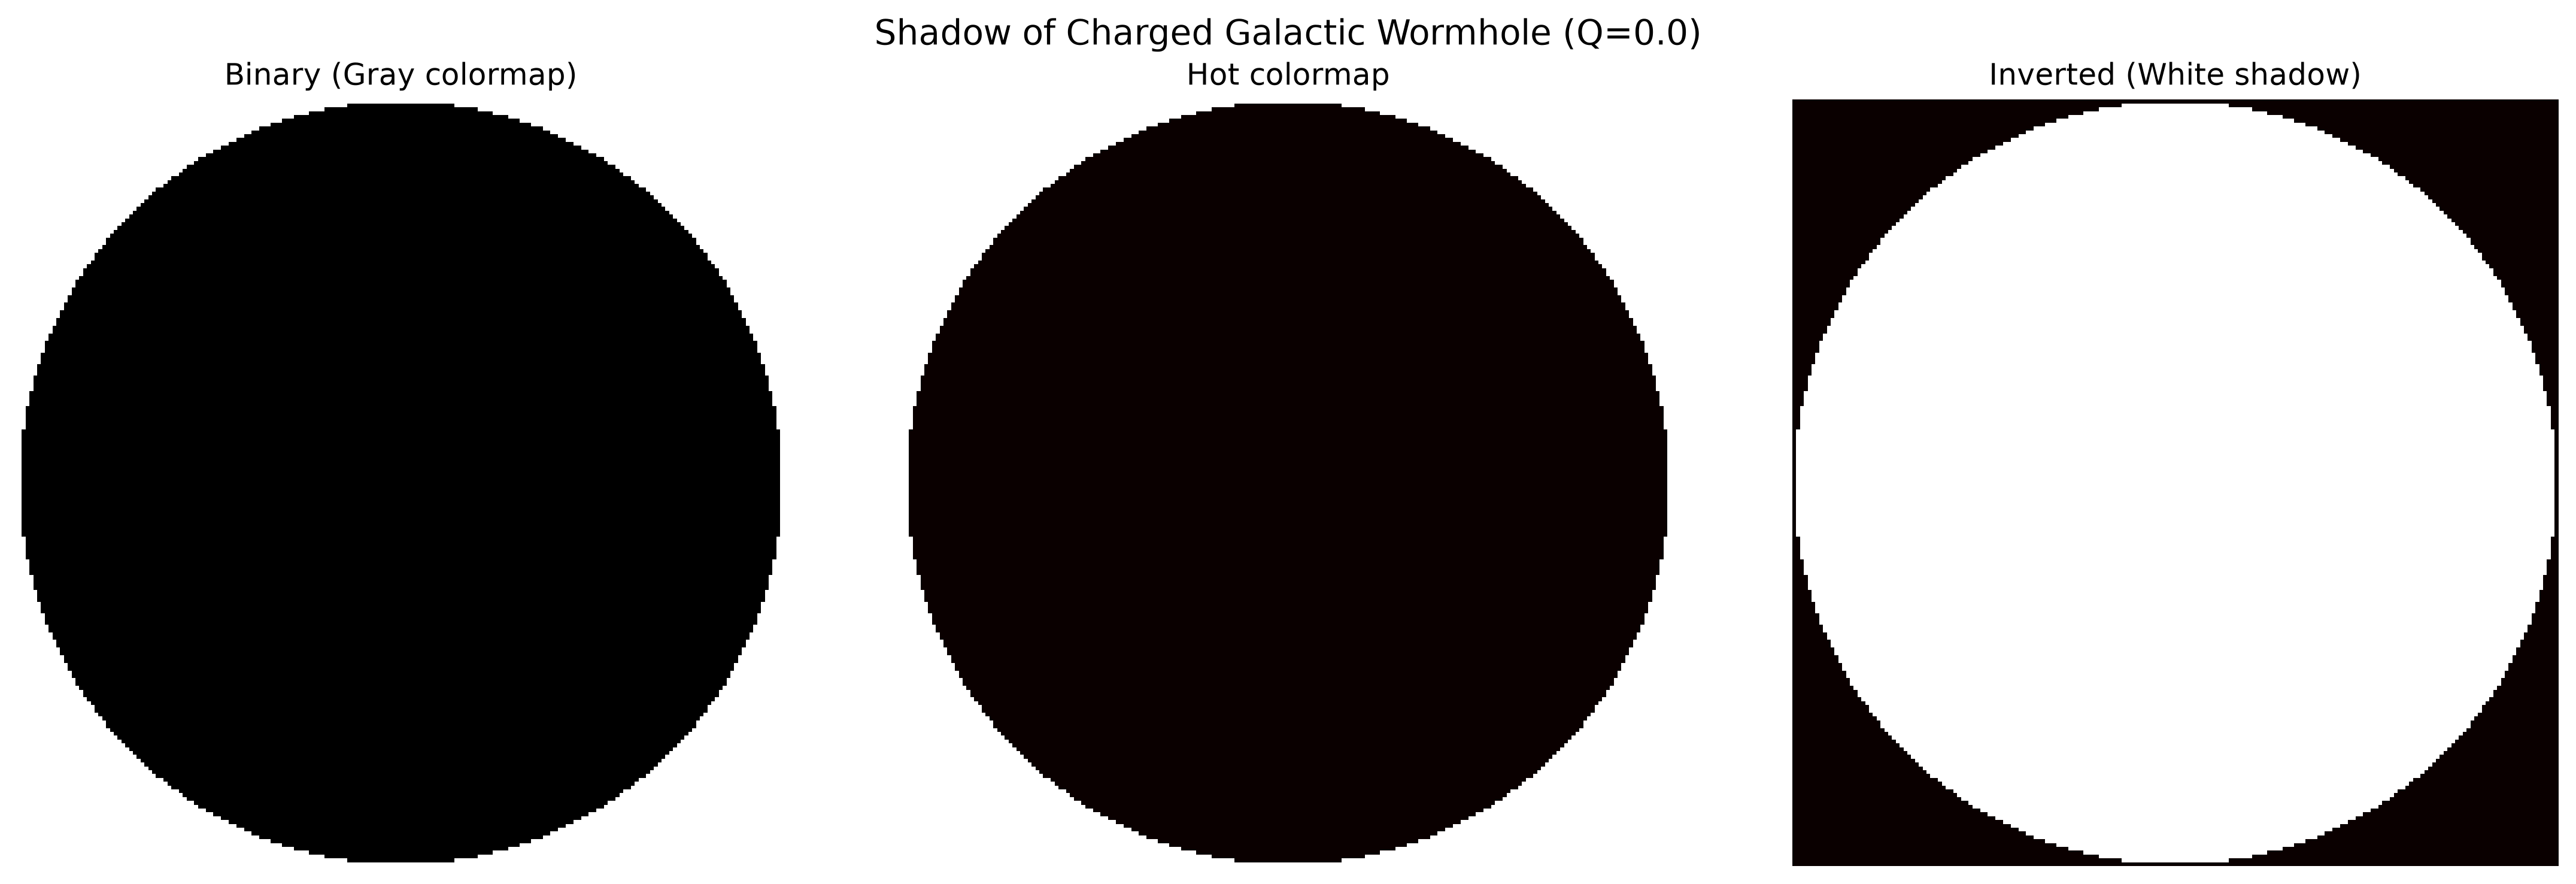

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Binary image (black on white)
axes[0].imshow(shadow_image, cmap='gray', origin='lower', vmin=0, vmax=1)
axes[0].set_title('Binary (Gray colormap)', fontsize=12)
axes[0].axis('off')

# 2. Hot colormap (black on yellow)
axes[1].imshow(shadow_image, cmap='hot', origin='lower', vmin=0, vmax=1)
axes[1].set_title('Hot colormap', fontsize=12)
axes[1].axis('off')

# 3. Inverted (white shadow on black)
axes[2].imshow(1 - shadow_image, cmap='hot', origin='lower')
axes[2].set_title('Inverted (White shadow)', fontsize=12)
axes[2].axis('off')

plt.suptitle(f'Shadow of Charged Galactic Wormhole (Q={Q})', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/shadows/static/shadow_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



Generating better shadow visualization...


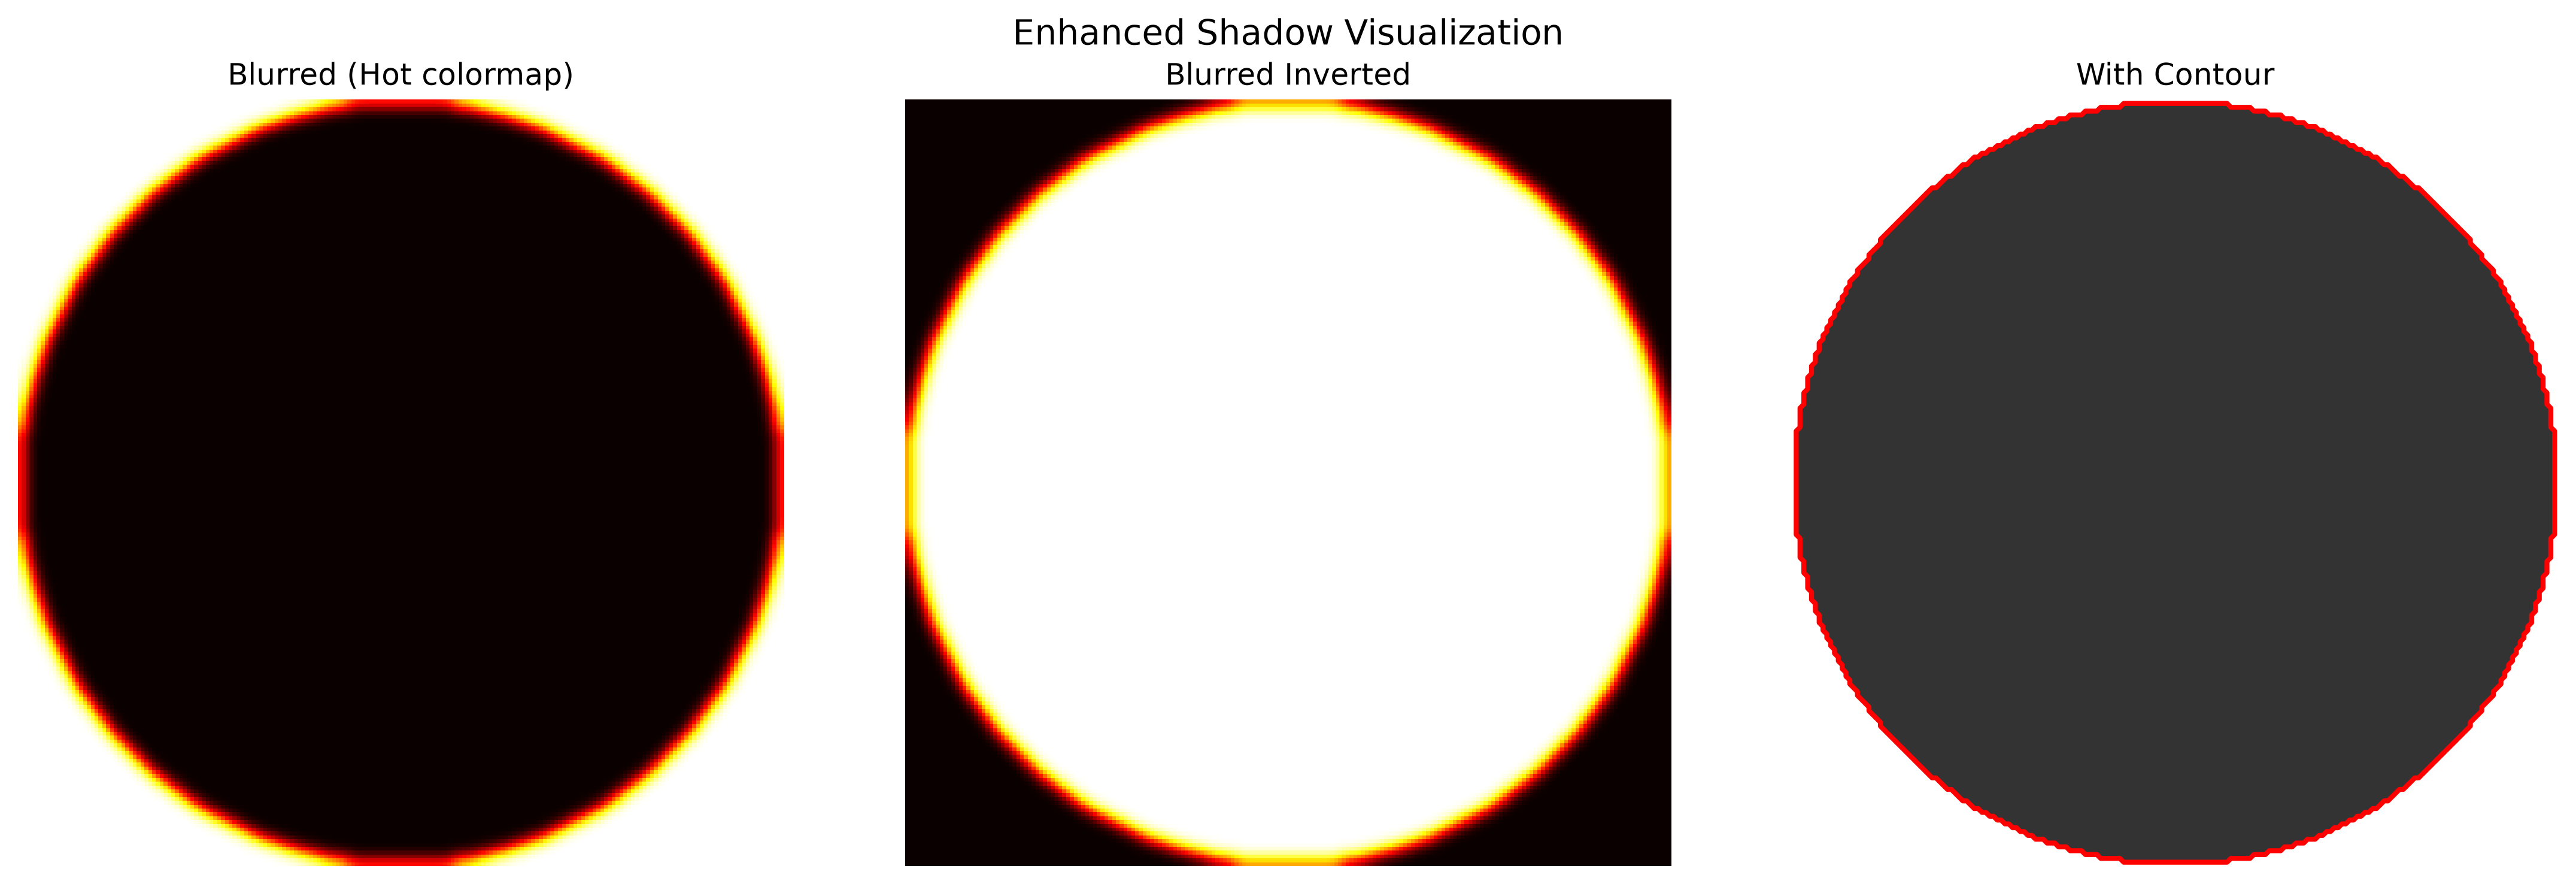


 Shadow visualization complete!
Files saved:
  - plots/shadows/static/shadow_comparison.png
  - plots/shadows/static/enhanced_shadow.png


In [30]:
# 2: Create a better shadow image

print("\nGenerating better shadow visualization...")

# Create a Gaussian blur for better visualization
from scipy.ndimage import gaussian_filter

# Blur the shadow to make it visible
shadow_blurred = gaussian_filter(shadow_image.astype(float), sigma=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 4. Blurred shadow
axes[0].imshow(shadow_blurred, cmap='hot', origin='lower')
axes[0].set_title('Blurred (Hot colormap)', fontsize=12)
axes[0].axis('off')

# 5. Blurred inverted
axes[1].imshow(1 - shadow_blurred, cmap='hot', origin='lower')
axes[1].set_title('Blurred Inverted', fontsize=12)
axes[1].axis('off')

# 6. With contour
axes[2].imshow(shadow_image, cmap='gray', origin='lower', alpha=0.8)
axes[2].contour(shadow_image, levels=[0.5], colors='red', linewidths=2)
axes[2].set_title('With Contour', fontsize=12)
axes[2].axis('off')

plt.suptitle('Enhanced Shadow Visualization', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/shadows/static/enhanced_shadow.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Shadow visualization complete!")
print("Files saved:")
print("  - plots/shadows/static/shadow_comparison.png")
print("  - plots/shadows/static/enhanced_shadow.png")